In [5]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/fred-economic-agent/data/processed/economic_dataset.csv',
                  index_col='Date', parse_dates=True)

print(df.shape)
df.head()

Mounted at /content/drive
(590, 13)


,Unemployment Rate,CPI (All Items),Industrial Production Index,Federal Funds Rate,10-Year Treasury Yield,2-Year Treasury Yield,Real GDP,NBER Recession Indicator (target),Yield Curve Spread,Inflation Rate,Unemployment Change,Industrial Production Growth,Recession
Date,,,,,,,,,,,,,
1977-06-01,7.2,60.5,48.0116,5.39,7.275455,6.127273,6654.466,0.0,1.148182,6.701940,0.2,9.207369,0
1977-07-01,6.9,60.8,48.0730,5.42,7.330000,6.274737,6774.457,0.0,1.055263,6.666667,-0.3,8.727759,0
1977-08-01,7.0,61.1,48.1205,5.90,7.396522,6.611304,6774.457,0.0,0.785217,6.631763,0.1,8.091747,0
1977-09-01,6.8,61.3,48.3189,6.14,7.343810,6.714286,6774.457,0.0,0.629524,6.423611,-0.2,8.163485,0
1977-10-01,6.8,61.6,48.3871,6.47,7.523500,7.106000,6774.592,0.0,0.417500,6.390328,0.0,8.349138,0


In [6]:
import matplotlib.pyplot as plt

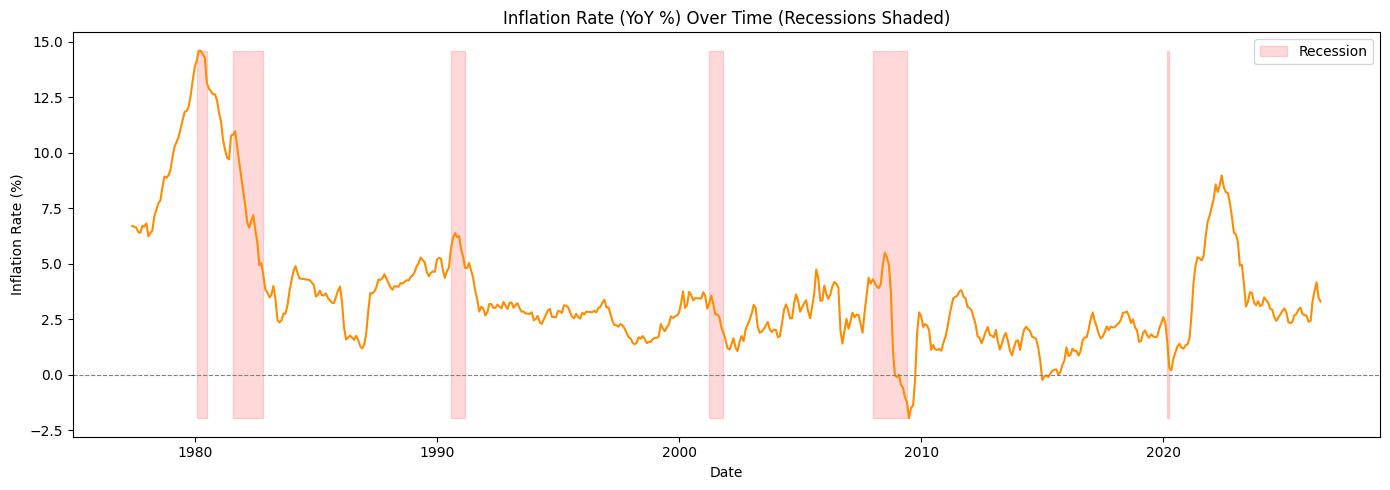

In [7]:
# --- Inflation Rate trend with recession periods shaded ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['Inflation Rate'], color='darkorange', linewidth=1.5)

in_recession = df['Recession'] == 1
ax.fill_between(df.index, df['Inflation Rate'].min(), df['Inflation Rate'].max(),
                 where=in_recession, color='red', alpha=0.15, label='Recession')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')  # zero line for reference
ax.set_title('Inflation Rate (YoY %) Over Time (Recessions Shaded)')
ax.set_ylabel('Inflation Rate (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

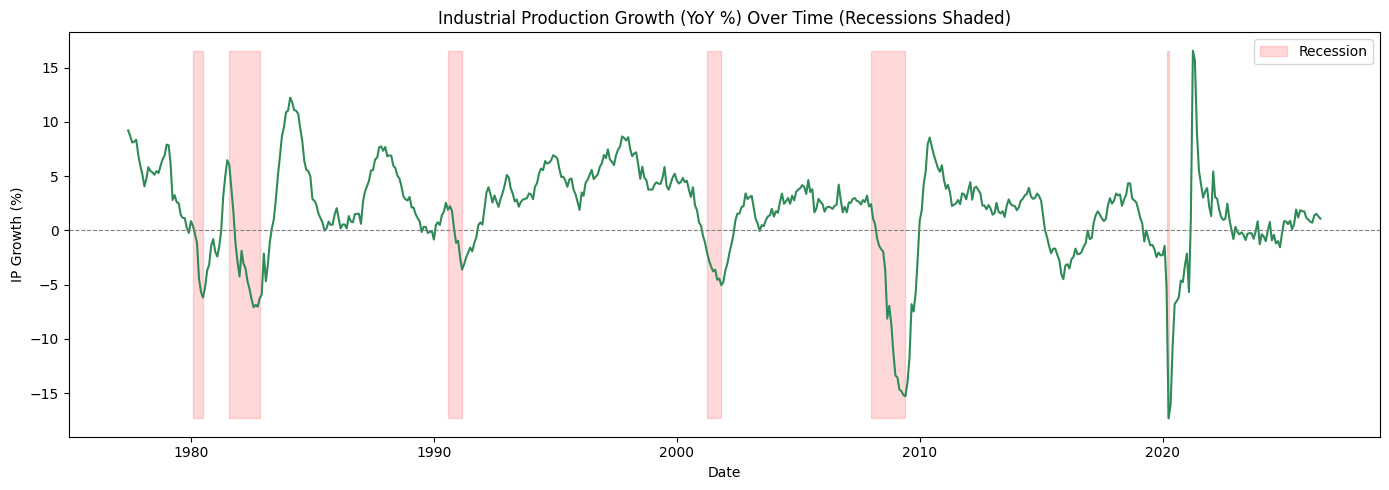

In [8]:
# --- Industrial Production Growth trend with recession periods shaded ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['Industrial Production Growth'], color='seagreen', linewidth=1.5)

ax.fill_between(df.index, df['Industrial Production Growth'].min(), df['Industrial Production Growth'].max(),
                 where=in_recession, color='red', alpha=0.15, label='Recession')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Industrial Production Growth (YoY %) Over Time (Recessions Shaded)')
ax.set_ylabel('IP Growth (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
import seaborn as sns

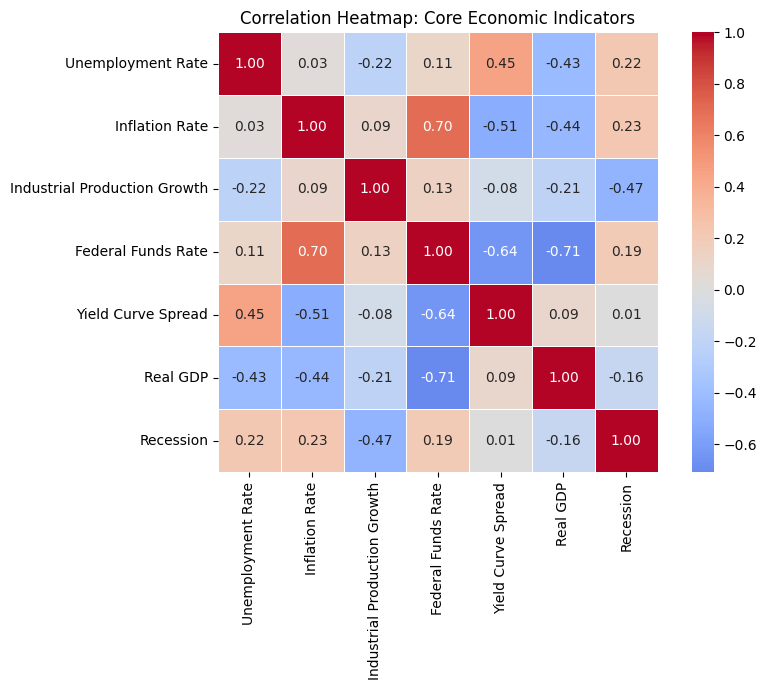

In [10]:
# --- Correlation heatmap across key indicators ---

# Pick the core indicators (avoid redundant raw+derived duplicates for clarity)
cols_for_corr = [
    'Unemployment Rate', 'Inflation Rate', 'Industrial Production Growth',
    'Federal Funds Rate', 'Yield Curve Spread', 'Real GDP', 'Recession'
]

corr_matrix = df[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap: Core Economic Indicators')
plt.tight_layout()
plt.show()

In [11]:
# --- Does yield curve inversion LEAD recessions? Test with a lag ---
# Shift the Recession column backward so we're comparing today's yield spread
# to whether a recession started in the NEXT 12 months
df['Recession_within_12mo'] = df['Recession'].shift(-12).rolling(12, min_periods=1).max()

lagged_corr = df[['Yield Curve Spread', 'Recession_within_12mo']].corr().iloc[0, 1]
print(f"Correlation between Yield Curve Spread and Recession within next 12 months: {lagged_corr:.2f}")

Correlation between Yield Curve Spread and Recession within next 12 months: -0.33


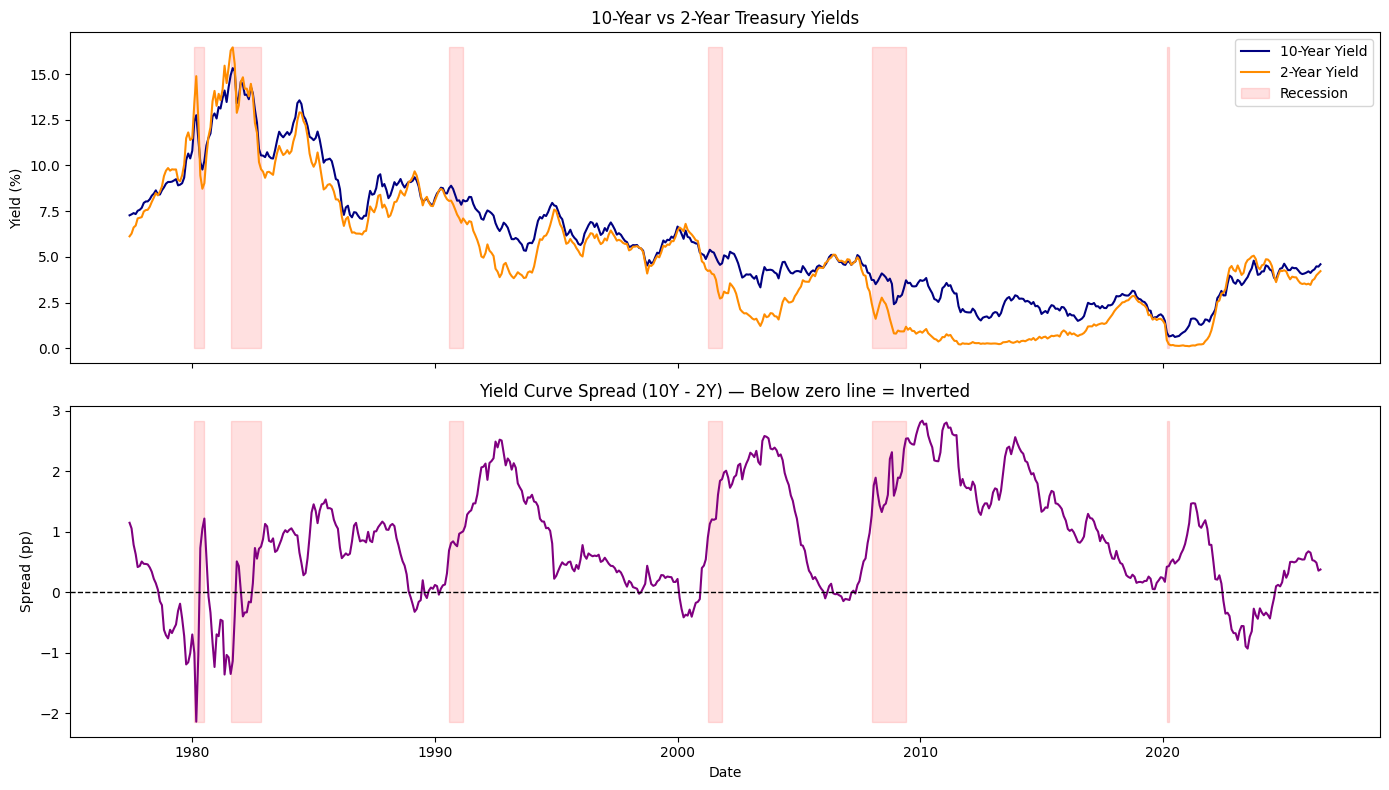

In [12]:
# --- Yield curve visualization: 10Y, 2Y yields and the spread together ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel: raw 10Y and 2Y yields
ax1.plot(df.index, df['10-Year Treasury Yield'], label='10-Year Yield', color='navy')
ax1.plot(df.index, df['2-Year Treasury Yield'], label='2-Year Yield', color='darkorange')
ax1.fill_between(df.index, 0, df[['10-Year Treasury Yield','2-Year Treasury Yield']].max().max(),
                  where=(df['Recession'] == 1), color='red', alpha=0.12, label='Recession')
ax1.set_title('10-Year vs 2-Year Treasury Yields')
ax1.set_ylabel('Yield (%)')
ax1.legend()

# Bottom panel: the spread, with zero line marking inversion
ax2.plot(df.index, df['Yield Curve Spread'], color='purple')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')  # spread < 0 = inversion
ax2.fill_between(df.index, df['Yield Curve Spread'].min(), df['Yield Curve Spread'].max(),
                  where=(df['Recession'] == 1), color='red', alpha=0.12)
ax2.set_title('Yield Curve Spread (10Y - 2Y) — Below zero line = Inverted')
ax2.set_ylabel('Spread (pp)')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

In [13]:
# --- Distribution analysis for core indicators ---
indicators_to_analyze = [
    'Unemployment Rate', 'Inflation Rate', 'Industrial Production Growth',
    'Federal Funds Rate', 'Yield Curve Spread'
]

summary_stats = df[indicators_to_analyze].describe().T  # mean, std, min, quartiles, max
summary_stats['median'] = df[indicators_to_analyze].median()

# Outlier detection using IQR method
def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

summary_stats['outlier_count'] = [count_outliers_iqr(df[col]) for col in indicators_to_analyze]

# Reorder columns for readability
summary_stats = summary_stats[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'outlier_count']]
summary_stats

,mean,median,std,min,25%,50%,75%,max,outlier_count
Unemployment Rate,6.008136,5.700000,1.764785,3.400000,4.600000,5.700000,7.100000,14.800000,3
Inflation Rate,3.608755,2.899365,2.723773,-1.958761,2.012836,2.899365,4.184054,14.592275,57
Industrial Production Growth,1.741183,2.221345,4.217278,-17.318282,-0.131842,2.221345,4.097080,16.552135,31
Federal Funds Rate,4.639000,4.580000,3.946291,0.050000,1.160000,4.580000,6.575000,19.100000,16
Yield Curve Spread,0.837603,0.745789,0.917225,-2.135714,0.185804,0.745789,1.467974,2.834211,1


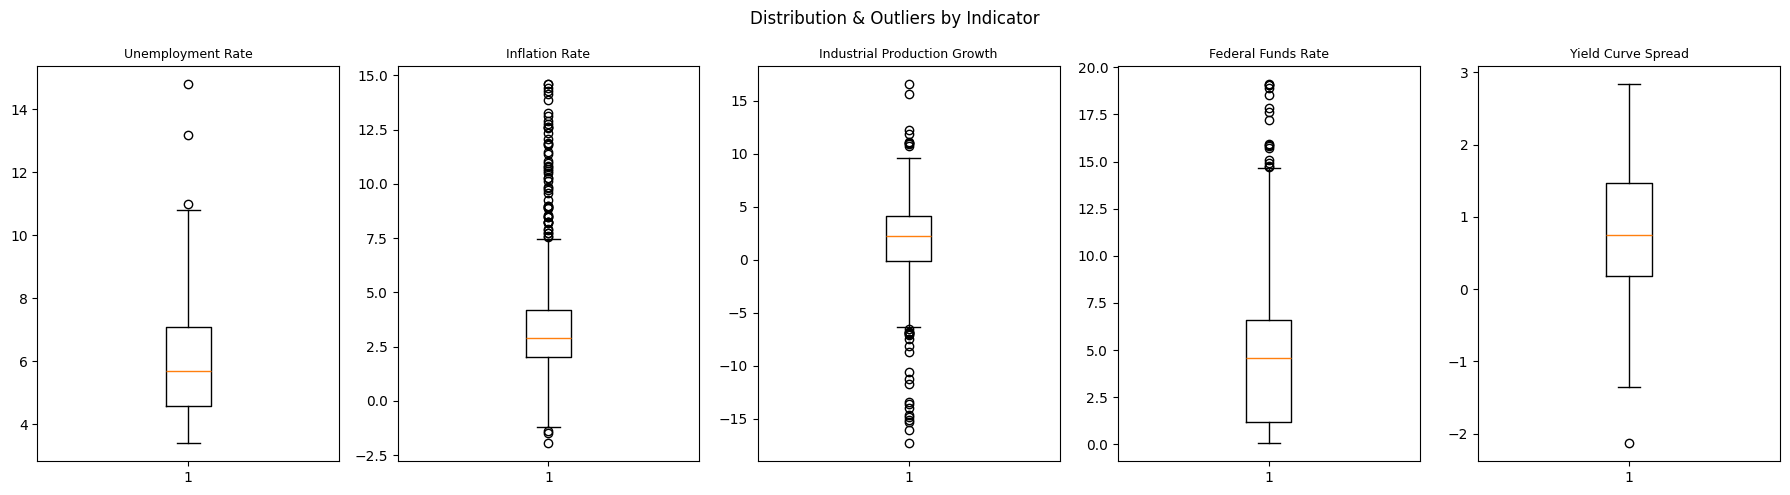

In [14]:
# --- Boxplots to visually show distribution + outliers ---
fig, axes = plt.subplots(1, len(indicators_to_analyze), figsize=(18, 5))

for ax, col in zip(axes, indicators_to_analyze):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col, fontsize=9)

plt.suptitle('Distribution & Outliers by Indicator')
plt.tight_layout()
plt.show()

Phase 5 & 6 (EDA + Statistical Analysis): ✅ complete.